In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal


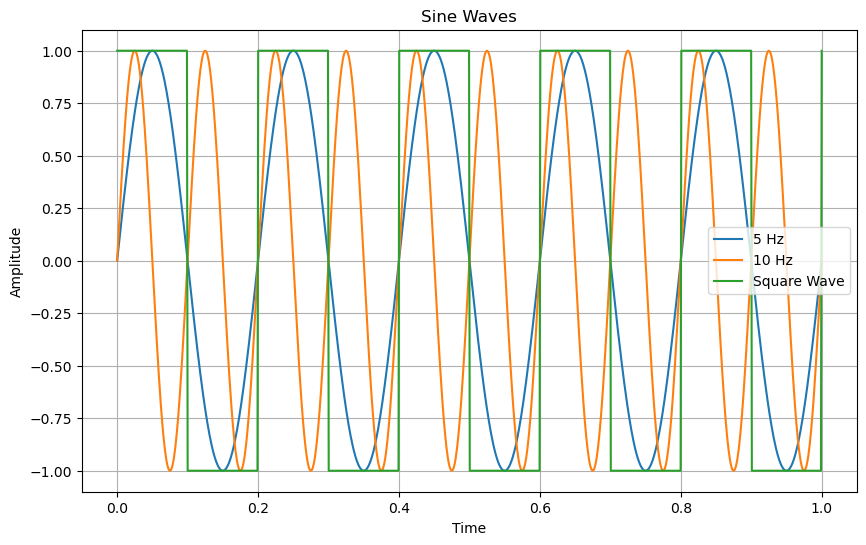

In [12]:
n = np.linspace(0,1, 1000)
x1 = np.sin(2 * np.pi * 5 * n)
x2 = np.sin(2 * np.pi * 10 * n)
x3 = signal.square(2 * np.pi * 5 * n)

plt.figure(figsize=(10,6))
plt.plot(n, x1, label='5 Hz')
plt.plot(n, x2, label='10 Hz')  
plt.plot(n, x3, label='Square Wave')
plt.title('Sine Waves')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.grid()
plt.legend()
plt.show()

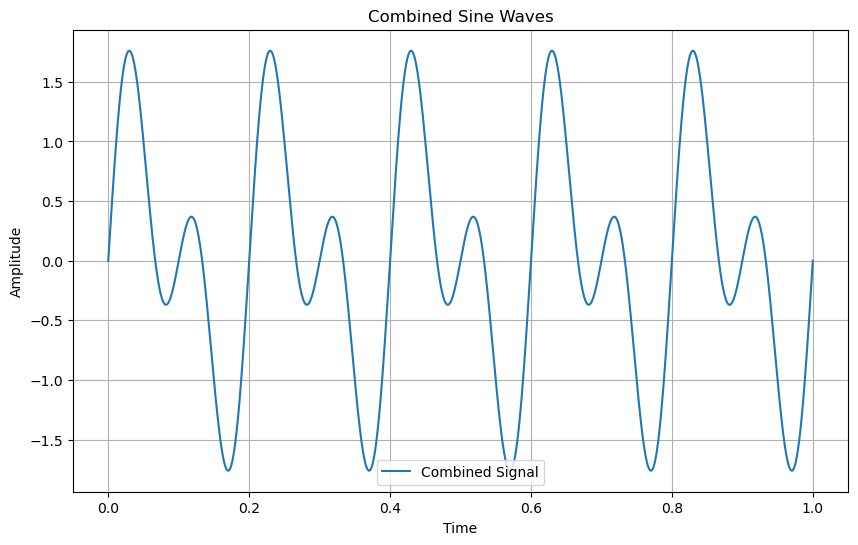

In [3]:
x_combined = x1 + x2
plt.figure(figsize=(10,6))
plt.plot(n, x_combined, label='Combined Signal')
plt.title('Combined Sine Waves')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.grid()
plt.legend()
plt.show()

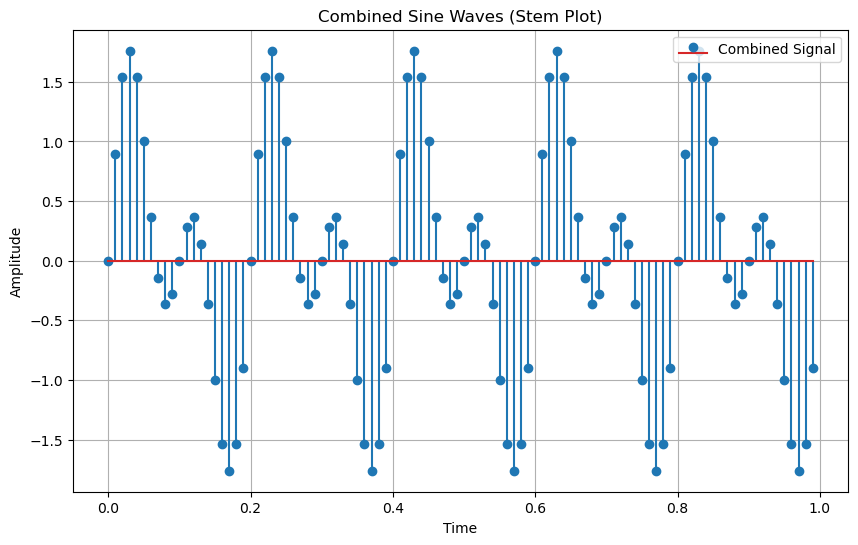

In [4]:
n = 100
n = np.arange(0,1, 1/n)
X1 = np.sin(2 * np.pi * 5 * n)
X2 = np.sin(2 * np.pi * 10 * n)

X = X1 + X2
plt.figure(figsize=(10,6))
plt.stem(n, X, label='Combined Signal')
plt.title('Combined Sine Waves (Stem Plot)')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.grid()
plt.legend()
plt.show()


In [5]:
def convolution(x, h):
    N = len(x)
    M = len(h)
    y_len = N + M - 1
    y = np.zeros(y_len)
    for n in range(y_len):
        for k in range(M):
            if 0 <= n-k < N:
                y[n] += x[n-k] * h[k]
    return y

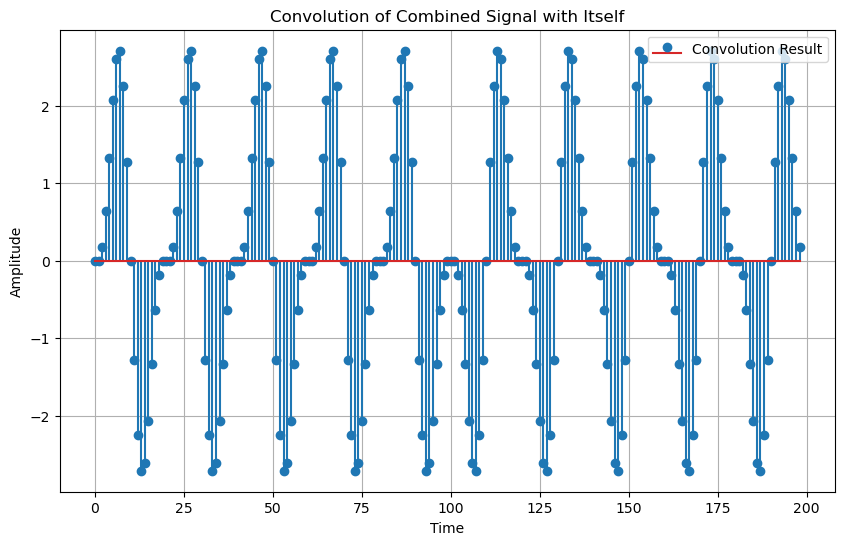

In [14]:
# y_conv = np.convolve(X1, X2)
y_conv = convolution(X1, X2)
plt.figure(figsize=(10,6))
plt.stem(np.arange(len(y_conv)), y_conv, label='Convolution Result')
plt.title('Convolution of Combined Signal with Itself')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.grid()
plt.legend()
plt.show()


In [7]:
def correlation(x, h):
    N = len(x)
    M = len(h)
    h  = h[::-1]  
    r_len = N + M - 1
    r = np.zeros(r_len)
    for n in range(r_len):
        for k in range(M):
            if 0 <= n-k < N:
                r[n] += x[n-k] * h[k]
    return r

In [25]:
X1 = np.array([1, 1, 1, 1])
X2 = np.array([1, -1, 1, -1])

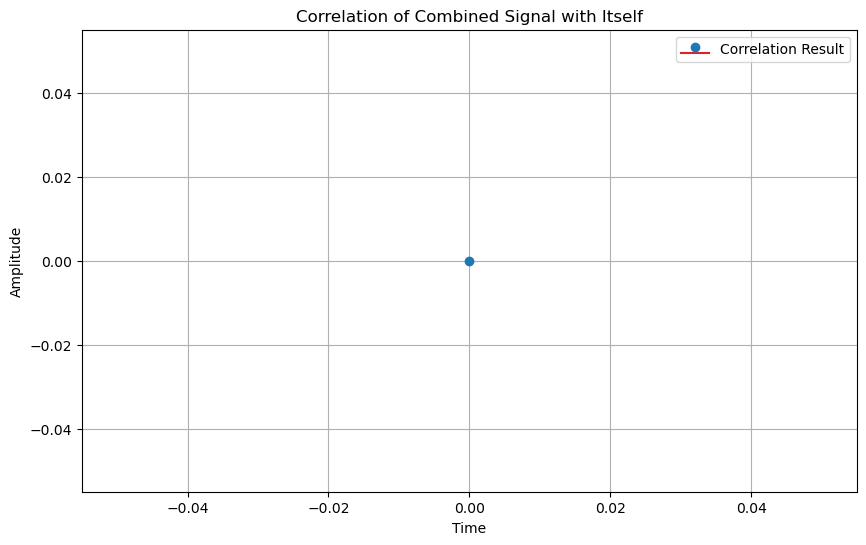

In [30]:
# y_corr = correlation(X1, X2)  # Correlate with reversed signal
y_corr = np.correlate(X1, X2)
lags = np.arange(-len(X1)+1, len(X1))

plt.figure(figsize=(10,6))  
plt.stem(np.arange(len(y_corr)), y_corr, label='Correlation Result')
plt.title('Correlation of Combined Signal with Itself')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.grid()
plt.legend()
plt.show()

In [9]:
def dft(x, N):
    n = len(x)
    X = np.zeros(N, dtype=complex)
    for k in range(N):
        for m in range(n):
            X[k] += x[m] * np.exp(-2j * np.pi * k * m / N)
    return X


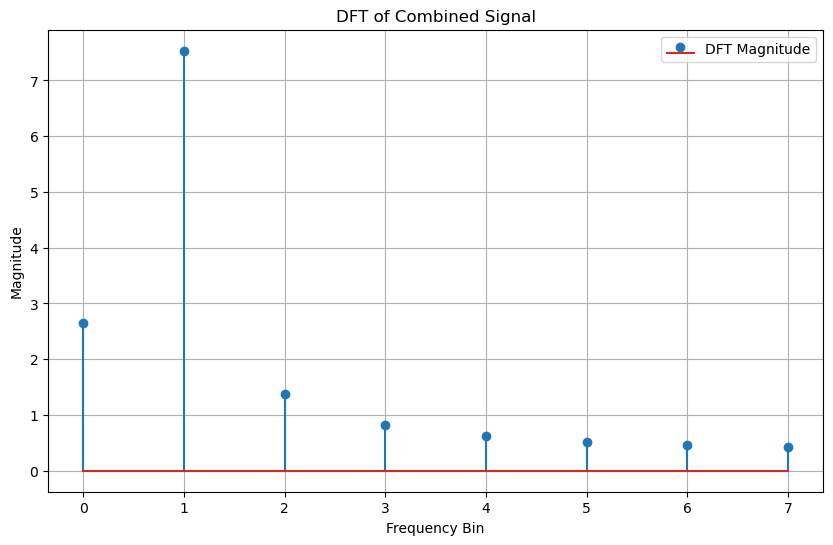

In [10]:
N = 16
x_dft = np.fft.fft(X1, N)
x_dft_mag = np.abs(x_dft)
x_dft_phase = np.angle(x_dft)

x_dft_freqs = np.fft.fftfreq(N, d=1/N)

plt.figure(figsize=(10,6))
plt.stem(x_dft_freqs[:N//2], x_dft_mag[:N//2], label='DFT Magnitude')
plt.title('DFT of Combined Signal')
plt.xlabel('Frequency Bin')
plt.ylabel('Magnitude')
plt.grid()
plt.legend()
plt.show()


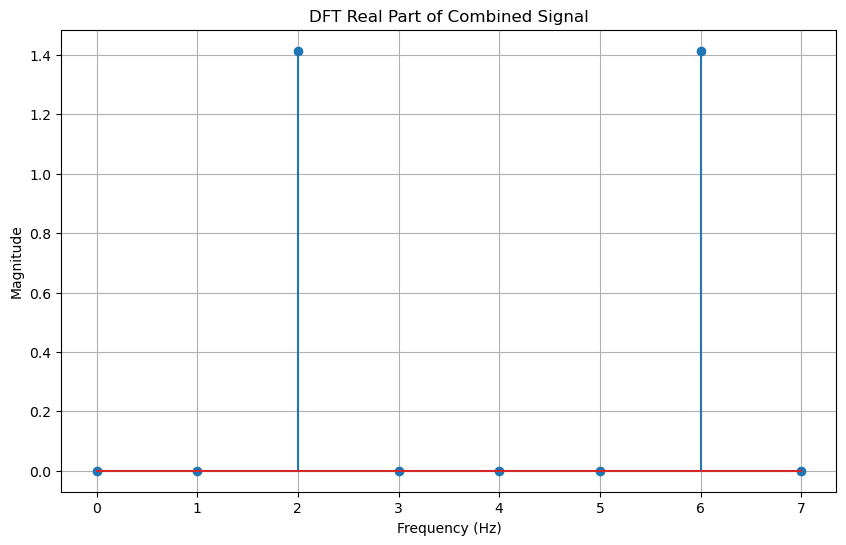

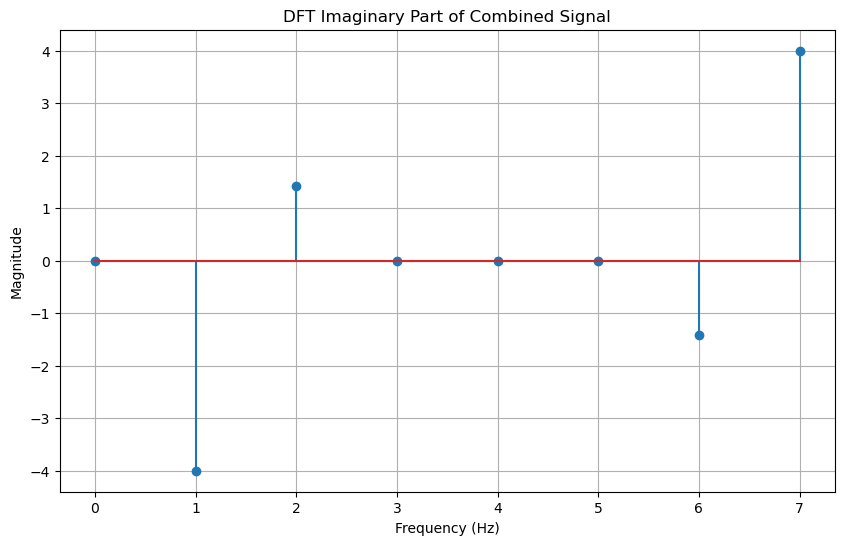

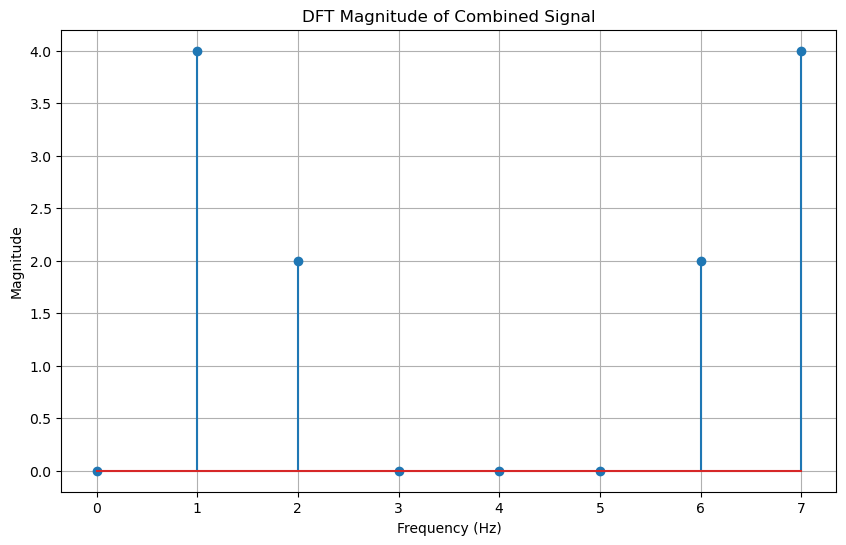

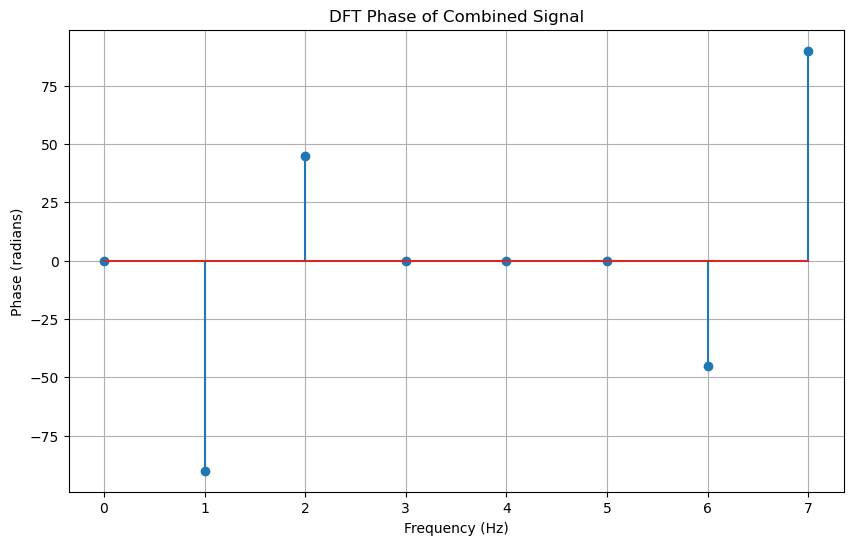

In [11]:
# Sampling frequency
fs = 8000  

# Number of DFT points
N = 8

# Sample indices (ONLY 8 samples as in the example)
n = np.arange(N)

# Time vector
t = n / fs  

# Signal components
x1 = np.sin(2 * np.pi * 1000 * t)
x2 = 0.5 * np.sin(2 * np.pi * 2000 * t + 3 * np.pi / 4)

# Combined signal
x_combined = x1 + x2

# DFT (use numpy FFT instead of custom unless required)
x_dft = np.fft.fft(x_combined, N)

# Magnitude and phase
x_dft_mag = np.abs(x_dft)
x_dft_real = np.real(x_dft)
x_dft_imag = np.imag(x_dft)
x_phase = np.angle(x_dft)
x_phase = np.degrees(x_phase)  # Convert to degrees for better interpretability
x_phase_clean = np.where(x_dft_mag > 1e-6, x_phase, 0)  # Clean phase for near-zero magnitudes

# Frequency axis (correct labeling)
freqs = np.arange(N) 

plt.figure(figsize=(10, 6))
plt.stem(freqs, x_dft_real, label='Real Part')
plt.title('DFT Real Part of Combined Signal')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
plt.stem(freqs, x_dft_imag, label='Imaginary Part')
plt.title('DFT Imaginary Part of Combined Signal')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.grid()
plt.show()


# ---- Plot Magnitude ----
plt.figure(figsize=(10, 6))
plt.stem(freqs, x_dft_mag)
plt.title('DFT Magnitude of Combined Signal')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.grid()
plt.show()

# ---- Plot Phase ----
plt.figure(figsize=(10, 6))
plt.stem(freqs, x_phase_clean)
plt.title('DFT Phase of Combined Signal')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Phase (radians)')
plt.grid()
plt.show()